# Tuần 07 — Thực hành k-Means: 3 bài

Demo `03_Demo-kMeans.ipynb` gom cụm bằng tay trên dữ liệu giả 2 chiều.

File này có **3 bài**. Mỗi bài là một bộ dữ liệu thật trên Kaggle. Cả 3 bài đều làm. Dùng `sklearn.cluster.KMeans`.

Clustering không chia train/test và không có nhãn để học. `StandardScaler` fit trên toàn bộ bảng feature. Không đưa cột ID hay tên vào khoảng cách.

Tải 3 file vào `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Mall Customer Segmentation | https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python | `data/Mall_Customers.csv` |
| 2 | Unsupervised Learning on Country Data | https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data | `data/Country-data.csv` |
| 3 | Wholesale Customers | https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set | `data/Wholesale customers data.csv` |

Ba bộ này cũng được dùng ở `09_TH-DBSCAN.ipynb`, để so sánh hai cách gom cụm trên cùng dữ liệu.


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)


## Phần chung

Elbow: với mỗi `K` từ 1 đến `k_max`, fit `KMeans` (`n_init=10`, `random_state=3000`), lưu `inertia_`, rồi vẽ. Chỗ khuỷu tay là `K` nên thử.

Sau khi có nhãn, bảng trung bình theo cụm giúp đọc ý nghĩa từng nhóm.


In [2]:
def ve_elbow(X_scaled, k_max=10):
    ks = list(range(1, k_max + 1))
    inertias = []
    for k in ks:
        model = KMeans(n_clusters=k, n_init=10, random_state=3000)
        model.fit(X_scaled)
        inertias.append(model.inertia_)
    plt.figure(figsize=(6, 4))
    plt.plot(ks, inertias, marker='o')
    plt.xlabel('K')
    plt.ylabel('inertia')
    plt.grid(True)
    plt.show()
    return ks, inertias


def bang_trung_binh(df_goc, labels, cot_so):
    tam = df_goc[cot_so].copy()
    tam['cum'] = labels
    return tam.groupby('cum').mean().round(2)


---

# Bài 1 — Khách hàng trung tâm thương mại

Nguồn: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

200 khách. Cột: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.

Bài này chỉ dùng **thu nhập** và **điểm chi tiêu**. Bỏ `CustomerID`. Không đưa `Gender` vào khoảng cách. Có thể để `Age` sang một lần chạy riêng nếu còn thời gian.

Chuẩn hóa hai cột, vẽ elbow, chọn `K`, tô màu scatter theo cụm. Dấu `x` là tâm cụm tính trên **số gốc** (trung bình thu nhập và điểm chi tiêu của các điểm trong cụm), để đọc được đơn vị thật.


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


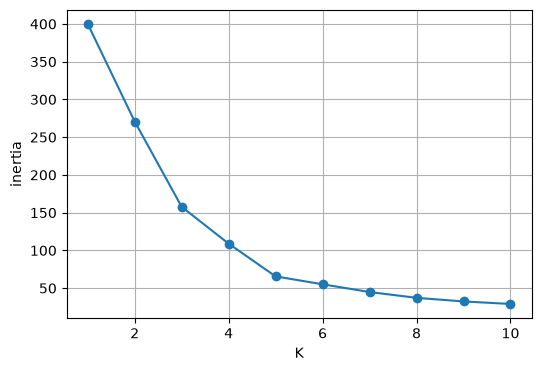

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [400.0,
  270.6682049684468,
  157.70400815035947,
  108.92131661364357,
  65.5684081557168,
  55.10377812115057,
  44.86628627232253,
  37.18175782682131,
  32.377243774440345,
  29.07617685124427])

In [3]:
mall = pd.read_csv('data/Mall_Customers.csv')
print(mall.head())
print(mall.shape)

cot = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall[cot].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_elbow(X_scaled)


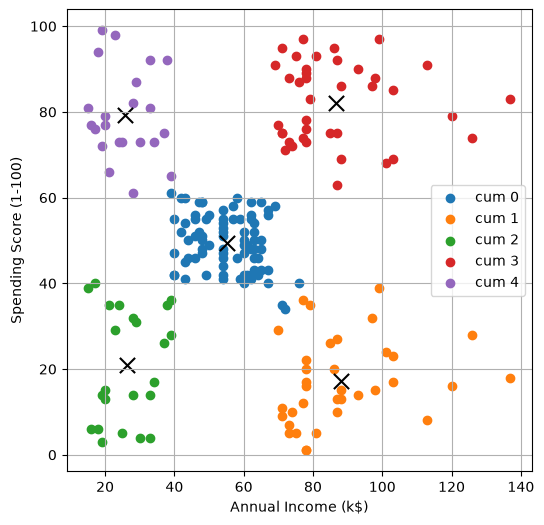

     Annual Income (k$)  Spending Score (1-100)
cum                                            
0                 55.30                   49.52
1                 88.20                   17.11
2                 26.30                   20.91
3                 86.54                   82.13
4                 25.73                   79.36
so diem moi cum: (array([0, 1, 2, 3, 4], dtype=int32), array([81, 35, 23, 39, 22]))


In [4]:
K = 5  # Chon tai khuc elbow cua bo du lieu Mall
model = KMeans(n_clusters=K, n_init=10, random_state=3000)
labels = model.fit_predict(X_scaled)

plt.figure(figsize=(6, 6))
for cum in np.unique(labels):
    pts = X[labels == cum]
    plt.scatter(pts[:, 0], pts[:, 1], label=f'cum {cum}')
    plt.scatter(pts[:, 0].mean(), pts[:, 1].mean(), c='black', marker='x', s=120)
plt.xlabel(cot[0])
plt.ylabel(cot[1])
plt.legend()
plt.grid(True)
plt.show()

print(bang_trung_binh(mall, labels, cot))
print('so diem moi cum:', np.unique(labels, return_counts=True))


**Nộp kèm bài 1**

1. `K` bạn chọn là bao nhiêu? Elbow gãy ở đâu?
2. Mô tả từng cụm bằng thu nhập và điểm chi tiêu (cao / thấp). Cụm nào đáng ưu tiên cho khuyến mãi?
3. Nếu thêm cột `Age` vào `X` rồi chuẩn hóa lại, bạn có đổi `K` không?


In [5]:
profiles = bang_trung_binh(mall, labels, cot)
print(f"1. Chon K={K} theo elbow; khuc gap nhin tren do thi la vung K xap xi 5.")
print('2. Trung binh thu nhap va spending score cua tung cum:')
print(profiles)
promo_cluster = profiles['Spending Score (1-100)'].idxmax()
print(f"Cum {promo_cluster} co spending score trung binh cao nhat ({profiles.loc[promo_cluster, 'Spending Score (1-100)']:.2f}), nen uu tien khuyen mai/giu chan.")
print('3. Them Age co the doi khoang cach, ranh gioi va elbow nen K co the thay doi; can ve elbow va danh gia lai thay vi mac dinh giu nguyen.')


1. Chon K=5 theo elbow; khuc gap nhin tren do thi la vung K xap xi 5.
2. Trung binh thu nhap va spending score cua tung cum:
     Annual Income (k$)  Spending Score (1-100)
cum                                            
0                 55.30                   49.52
1                 88.20                   17.11
2                 26.30                   20.91
3                 86.54                   82.13
4                 25.73                   79.36
Cum 3 co spending score trung binh cao nhat (82.13), nen uu tien khuyen mai/giu chan.
3. Them Age co the doi khoang cach, ranh gioi va elbow nen K co the thay doi; can ve elbow va danh gia lai thay vi mac dinh giu nguyen.


---

# Bài 2 — Phân nhóm quốc gia

Nguồn: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

167 nước, file `Country-data.csv`. Cột `country` là tên, không đưa vào `X`.

Các cột số: `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, `gdpp`.

`income` và `gdpp` lớn hơn `child_mort` rất nhiều. Bắt buộc `StandardScaler`. Chọn `K` bằng elbow (thường thử quanh 3). In trung bình `child_mort`, `income`, `life_expec`, `gdpp` theo cụm, và liệt kê khoảng 8 tên nước mỗi cụm.


               country  child_mort  exports  health  imports  income  inflation  life_expec  total_fer   gdpp
0          Afghanistan        90.2     10.0    7.58     44.9    1610       9.44        56.2       5.82    553
1              Albania        16.6     28.0    6.55     48.6    9930       4.49        76.3       1.65   4090
2              Algeria        27.3     38.4    4.17     31.4   12900      16.10        76.5       2.89   4460
3               Angola       119.0     62.3    2.85     42.9    5900      22.40        60.1       6.16   3530
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100       1.44        76.8       2.13  12200
(167, 10)


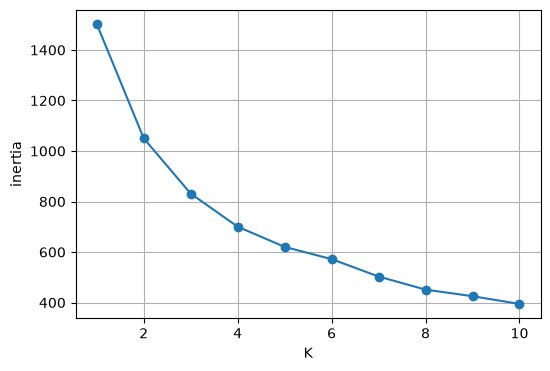

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [1503.0,
  1050.2145582853304,
  831.4244352086874,
  700.3917199643637,
  620.4488115302203,
  572.0890405033384,
  503.09485507350826,
  451.323648529166,
  425.2063439940849,
  394.56762525044974])

In [6]:
country = pd.read_csv('data/Country-data.csv')
print(country.head())
print(country.shape)

cot_so = [c for c in country.columns if c != 'country']
X_scaled = StandardScaler().fit_transform(country[cot_so].to_numpy(dtype=float))

ve_elbow(X_scaled)


In [7]:
K = 3  # Thu quanh K=3 theo goi y va khuc elbow
labels = KMeans(n_clusters=K, n_init=10, random_state=3000).fit_predict(X_scaled)

print(bang_trung_binh(country, labels, ['child_mort', 'income', 'life_expec', 'gdpp']))

for cum in np.unique(labels):
    ten = country.loc[labels == cum, 'country'].head(8).tolist()
    print(cum, ten)


     child_mort    income  life_expec      gdpp
cum                                            
0         21.93  12305.60       72.81   6486.45
1         92.96   3942.40       59.19   1922.38
2          5.00  45672.22       80.13  42494.44
0 ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh']
1 ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic']
2 ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic']


**Nộp kèm bài 2**

1. `K` bạn chọn? Cụm nào có `child_mort` cao và `gdpp` thấp?
2. Kể tên 3 nước thuộc cụm đó và 3 nước thuộc cụm có `gdpp` cao.
3. Vì sao không chuẩn hóa thì `income` và `gdpp` sẽ át các cột còn lại?


In [8]:
country_profiles = bang_trung_binh(country, labels, ['child_mort', 'income', 'life_expec', 'gdpp'])
poor_cluster = country_profiles.sort_values(['child_mort', 'gdpp'], ascending=[False, True]).index[0]
rich_cluster = country_profiles['gdpp'].idxmax()
poor_countries = country.loc[labels == poor_cluster, 'country'].head(3).tolist()
rich_countries = country.loc[labels == rich_cluster, 'country'].head(3).tolist()
print(f"1. Chon K={K}; cum co child_mort cao va gdpp thap nhat theo profile la cum {poor_cluster}.")
print(f"2. Ba nuoc thuoc cum do: {poor_countries}; ba nuoc thuoc cum gdpp cao nhat (cum {rich_cluster}): {rich_countries}.")
print('3. Income va gdpp co bien do lon hon nhieu; khong chuan hoa thi phuong sai lon cua chung chi phoi khoang cach va lam mo anh huong cua cac cot con lai.')


1. Chon K=3; cum co child_mort cao va gdpp thap nhat theo profile la cum 1.
2. Ba nuoc thuoc cum do: ['Afghanistan', 'Angola', 'Benin']; ba nuoc thuoc cum gdpp cao nhat (cum 2): ['Australia', 'Austria', 'Bahrain'].
3. Income va gdpp co bien do lon hon nhieu; khong chuan hoa thi phuong sai lon cua chung chi phoi khoang cach va lam mo anh huong cua cac cot con lai.


---

# Bài 3 — Khách sỉ

Nguồn: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set

440 khách hàng bán sỉ. File `Wholesale customers data.csv`.

Cột: `Channel`, `Region`, `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

`Channel` (1 = Horeca, 2 = Retail) và `Region` là mã nhóm, không phải số tiền. **Không** đưa hai cột này vào `X`. Gom cụm trên 6 cột chi tiêu, sau chuẩn hóa. Rồi dùng `pd.crosstab` để xem mỗi cụm nằm ở kênh nào.


   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
(440, 8)


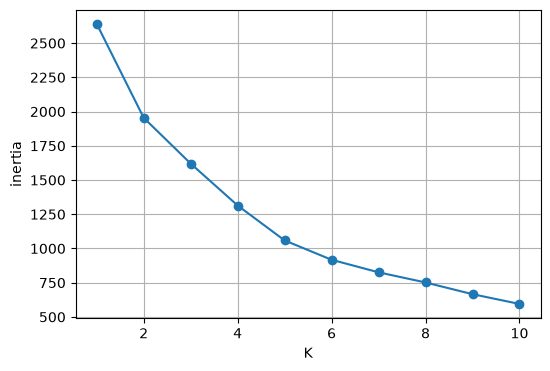

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [2640.0000000000005,
  1954.1835647259281,
  1619.952782172456,
  1313.7580090341148,
  1058.7712532570083,
  917.4454350272308,
  825.8359775416383,
  751.7362093470332,
  666.2237996202156,
  594.8556455931528])

In [9]:
ws = pd.read_csv('data/Wholesale customers data.csv')
print(ws.head())
print(ws.shape)

cot_chi = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X_scaled = StandardScaler().fit_transform(ws[cot_chi].to_numpy(dtype=float))

ve_elbow(X_scaled)


In [10]:
K = 5  # Chon theo elbow tren 6 cot chi tieu da chuan hoa
labels = KMeans(n_clusters=K, n_init=10, random_state=3000).fit_predict(X_scaled)

print(bang_trung_binh(ws, labels, cot_chi))
print(pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel']))


        Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
cum                                                                      
0    32957.98   4997.35   5884.76   8422.84            954.60     2462.97
1    36847.00  43950.00  20170.00  36534.00            239.00    47943.00
2    15964.90  34708.50  48536.90   3054.60          24875.20     2942.80
3     5754.17  10866.60  16607.10   1464.12           7202.88     1813.39
4     9092.16   2967.76   3807.41   2271.76            989.81      978.96
Channel    1   2
cum             
0         55   8
1          1   0
2          0  10
3          9  87
4        233  37


**Nộp kèm bài 3**

1. `K` bạn chọn? Cụm nào chi mạnh cho `Grocery` và `Detergents_Paper`?
2. Cụm đó lệch về `Channel` nào trên bảng crosstab?
3. So với bài 1: vì sao bài 3 không vẽ một scatter là đủ để đọc cụm?


In [11]:
profiles = bang_trung_binh(ws, labels, cot_chi)
channel_table = pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel'])
spend_score = profiles['Grocery'] + profiles['Detergents_Paper']
top_cluster = spend_score.idxmax()
print(f"1. Chon K={K}; cum chi manh nhat cho Grocery va Detergents_Paper la cum {top_cluster}.")
print(f"2. Crosstab cua cum nay: {channel_table.loc[top_cluster].to_dict()} (1=Horeca, 2=Retail).")
print('3. Sau khi gom 6 feature, scatter 2D chi the hien mot hinh chieu nen co the che mat cau truc; bang profile va crosstab giup so sanh tren tat ca feature.')


1. Chon K=5; cum chi manh nhat cho Grocery va Detergents_Paper la cum 2.
2. Crosstab cua cum nay: {1: 0, 2: 10} (1=Horeca, 2=Retail).
3. Sau khi gom 6 feature, scatter 2D chi the hien mot hinh chieu nen co the che mat cau truc; bang profile va crosstab giup so sanh tren tat ca feature.
